# Simple Entropy Adjacency Experiment (From Existing Log)

This notebook uses your existing baseline log to test whether adjacent-step entropy is similar.

Main checks:
- Distribution of raw entropy `H_t`
- Distribution of delta entropy `Δ_t = H_t - H_{t-1}`
- Lag-1 correlation `corr(H_t, H_{t-1})`
- Shuffled baseline correlation

Interpretation rule:
- If `Δ_t` clusters near 0 and lag-1 corr is clearly above shuffled, that is strong **supporting evidence**.
- It is not a formal proof by itself.


In [2]:
import json
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

plt.rcParams['figure.figsize'] = (7, 4)
plt.rcParams['axes.grid'] = True

LOG_PATH = Path('/c2/jenny/r3/entropy-attn-2026/logs/qa_2_entropy_attn_entropy_log_baseline_entropy_log_fixed_temp.jsonl')
EPS = 0.1  # nats
SEED = 7


In [3]:
def load_entropy_sequences(jsonl_path: Path):
    seqs = []
    with jsonl_path.open('r', encoding='utf-8') as f:
        for line in f:
            row = json.loads(line)
            log = row.get('entropy_log', [])
            h = [x.get('entropy_mean') for x in log if 'entropy_mean' in x]
            if len(h) >= 2:
                seqs.append(np.array(h, dtype=float))
    return seqs

seqs = load_entropy_sequences(LOG_PATH)
len(seqs), np.mean([len(s) for s in seqs])


(419, 4.248210023866348)

In [4]:
# Flattened raw entropy and delta arrays
H = np.concatenate(seqs) if seqs else np.array([])
D = np.concatenate([s[1:] - s[:-1] for s in seqs]) if seqs else np.array([])

# Adjacent pairs for correlation
x = np.concatenate([s[:-1] for s in seqs]) if seqs else np.array([])
y = np.concatenate([s[1:] for s in seqs]) if seqs else np.array([])

rng = np.random.default_rng(SEED)
x_shuf = x.copy()
rng.shuffle(x_shuf)

pearson_lag1 = np.corrcoef(x, y)[0, 1] if len(x) > 1 else np.nan
pearson_shuf = np.corrcoef(x_shuf, y)[0, 1] if len(x) > 1 else np.nan

summary = {
    'num_sequences_used': int(len(seqs)),
    'mean_sequence_length': float(np.mean([len(s) for s in seqs])) if seqs else np.nan,
    'num_entropy_points': int(H.size),
    'num_delta_points': int(D.size),
    'raw_entropy_mean': float(np.mean(H)) if H.size else np.nan,
    'raw_entropy_std': float(np.std(H)) if H.size else np.nan,
    'delta_mean': float(np.mean(D)) if D.size else np.nan,
    'delta_std': float(np.std(D)) if D.size else np.nan,
    f'frac_abs_delta_lt_{EPS}': float(np.mean(np.abs(D) < EPS)) if D.size else np.nan,
    'pearson_lag1': float(pearson_lag1),
    'pearson_lag1_shuffled': float(pearson_shuf),
}
summary


{'num_sequences_used': 419,
 'mean_sequence_length': 4.248210023866348,
 'num_entropy_points': 1780,
 'num_delta_points': 1361,
 'raw_entropy_mean': 2.77515658073211,
 'raw_entropy_std': 0.35358405313340296,
 'delta_mean': 0.12307165748139325,
 'delta_std': 0.4530484405955224,
 'frac_abs_delta_lt_0.1': 0.16311535635562086,
 'pearson_lag1': 0.18131913353879608,
 'pearson_lag1_shuffled': -0.0025068251666101582}

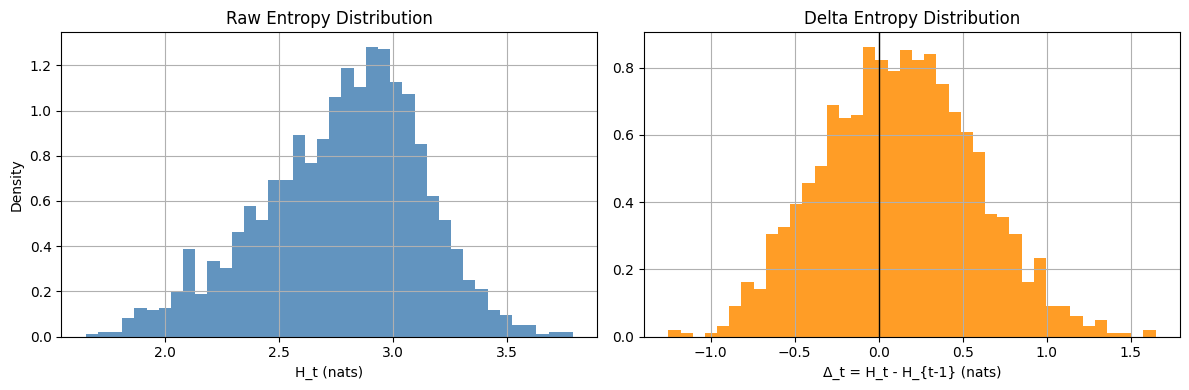

In [5]:
# Raw entropy vs delta distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(H, bins=40, alpha=0.85, color='steelblue', density=True)
axes[0].set_title('Raw Entropy Distribution')
axes[0].set_xlabel('H_t (nats)')
axes[0].set_ylabel('Density')

axes[1].hist(D, bins=40, alpha=0.85, color='darkorange', density=True)
axes[1].axvline(0.0, color='black', linewidth=1)
axes[1].set_title('Delta Entropy Distribution')
axes[1].set_xlabel('Δ_t = H_t - H_{t-1} (nats)')

plt.tight_layout()
plt.show()


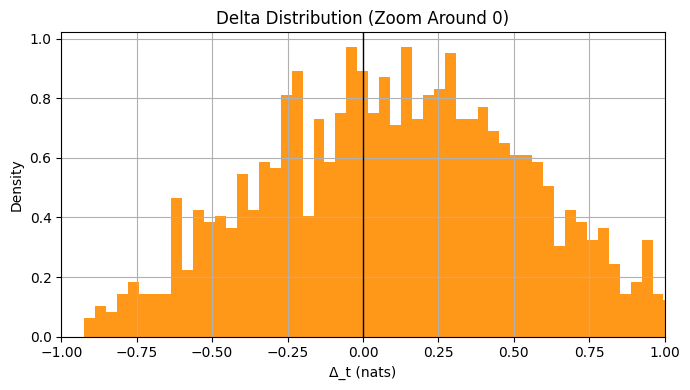

In [6]:
# Zoom near zero for deltas
plt.figure(figsize=(7, 4))
plt.hist(D, bins=80, density=True, color='darkorange', alpha=0.9)
plt.axvline(0.0, color='black', linewidth=1)
plt.xlim(-1.0, 1.0)
plt.title('Delta Distribution (Zoom Around 0)')
plt.xlabel('Δ_t (nats)')
plt.ylabel('Density')
plt.tight_layout()
plt.show()


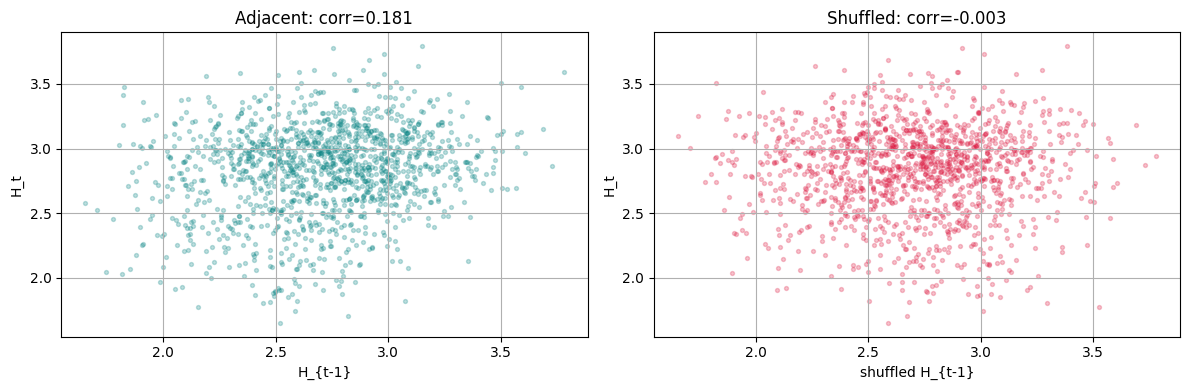

In [7]:
# Adjacent scatter and shuffled baseline
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

n_show = min(3000, len(x))
idx = np.random.default_rng(SEED).choice(len(x), size=n_show, replace=False) if len(x) else np.array([], dtype=int)

axes[0].scatter(x[idx], y[idx], s=8, alpha=0.25, color='teal')
axes[0].set_title(f'Adjacent: corr={pearson_lag1:.3f}')
axes[0].set_xlabel('H_{t-1}')
axes[0].set_ylabel('H_t')

axes[1].scatter(x_shuf[idx], y[idx], s=8, alpha=0.25, color='crimson')
axes[1].set_title(f'Shuffled: corr={pearson_shuf:.3f}')
axes[1].set_xlabel('shuffled H_{t-1}')
axes[1].set_ylabel('H_t')

plt.tight_layout()
plt.show()


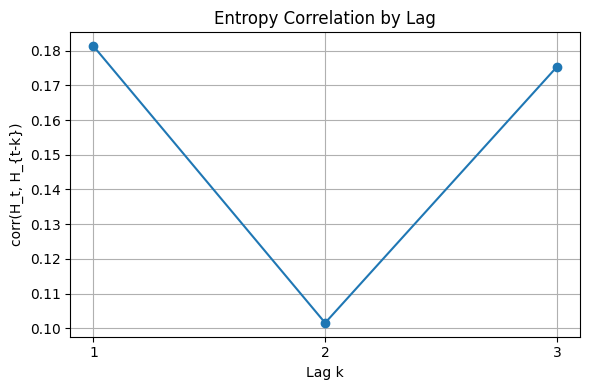

{1: 0.18131913353879608, 2: 0.1015272892396469, 3: 0.17533359748546481}

In [8]:
# Lightweight lag check
def lag_corr(sequences, lag):
    xs, ys = [], []
    for s in sequences:
        if len(s) > lag:
            xs.append(s[:-lag])
            ys.append(s[lag:])
    if not xs:
        return np.nan
    xx = np.concatenate(xs)
    yy = np.concatenate(ys)
    return np.corrcoef(xx, yy)[0, 1]

lags = [1, 2, 3]
lag_vals = [lag_corr(seqs, k) for k in lags]

plt.figure(figsize=(6, 4))
plt.plot(lags, lag_vals, marker='o')
plt.xticks(lags)
plt.xlabel('Lag k')
plt.ylabel('corr(H_t, H_{t-k})')
plt.title('Entropy Correlation by Lag')
plt.tight_layout()
plt.show()

dict(zip(lags, lag_vals))


## CDF For Local Smoothness (Recommended Figure)

This compares `|H_t - H_{t-k}|` across lags and a shuffled baseline.
A steeper CDF near 0 means stronger local entropy smoothness.


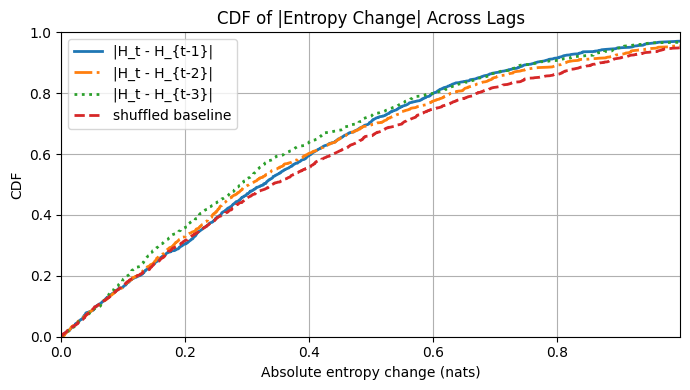

P(|Δ_1| < 0.05)=0.086 | shuffled=0.088
P(|Δ_1| < 0.10)=0.163 | shuffled=0.169
P(|Δ_1| < 0.20)=0.304 | shuffled=0.316
P(|Δ_1| < 0.30)=0.469 | shuffled=0.456


In [9]:
def abs_diffs_for_lag(sequences, lag):
    vals = []
    for s in sequences:
        if len(s) > lag:
            vals.append(np.abs(s[lag:] - s[:-lag]))
    return np.concatenate(vals) if vals else np.array([])

def ecdf(arr):
    if arr.size == 0:
        return np.array([]), np.array([])
    x = np.sort(arr)
    y = np.arange(1, len(x) + 1) / len(x)
    return x, y

abs_lag1 = abs_diffs_for_lag(seqs, 1)
abs_lag2 = abs_diffs_for_lag(seqs, 2)
abs_lag3 = abs_diffs_for_lag(seqs, 3)

# Shuffled baseline at lag-1
x1 = np.concatenate([s[:-1] for s in seqs if len(s) > 1])
y1 = np.concatenate([s[1:] for s in seqs if len(s) > 1])
rng = np.random.default_rng(SEED)
x1_shuf = x1.copy()
rng.shuffle(x1_shuf)
abs_shuf = np.abs(y1 - x1_shuf)

plt.figure(figsize=(7, 4))
for arr, label, style in [
    (abs_lag1, '|H_t - H_{t-1}|', '-'),
    (abs_lag2, '|H_t - H_{t-2}|', '-.'),
    (abs_lag3, '|H_t - H_{t-3}|', ':'),
    (abs_shuf, 'shuffled baseline', '--'),
]:
    xx, yy = ecdf(arr)
    if xx.size:
        plt.plot(xx, yy, linestyle=style, linewidth=2, label=label)

plt.xlim(0, np.quantile(abs_shuf, 0.95) if abs_shuf.size else 1.0)
plt.ylim(0, 1.0)
plt.xlabel('Absolute entropy change (nats)')
plt.ylabel('CDF')
plt.title('CDF of |Entropy Change| Across Lags')
plt.legend()
plt.tight_layout()
plt.show()

# Simple numeric anchors you can cite
for thr in [0.05, 0.1, 0.2, 0.3]:
    v1 = float(np.mean(abs_lag1 < thr)) if abs_lag1.size else np.nan
    vs = float(np.mean(abs_shuf < thr)) if abs_shuf.size else np.nan
    print(f'P(|Δ_1| < {thr:.2f})={v1:.3f} | shuffled={vs:.3f}')


## How To Read This

- `Δ_t` mass near 0 supports local entropy smoothness.
- Higher adjacent corr than shuffled baseline strengthens the claim.
- This log has short response lengths (few steps per sample), so treat this as **supporting evidence** only.
- For stronger evidence on your project assumption, repeat on token-level teacher-forced traces over longer contexts.
